In [52]:
import numpy as np
import matplotlib.pyplot as plt
from ctf_dataset.load import create_wrapped_dataset
from os.path import join
from coupling_metrics import phase_synchrony, isps, cofluctuation, iscf, window_isc, window_isfc
import scipy
from itertools import combinations
import pycwt
import pandas as pd
import seaborn as sns
import sklearn

from sklearn import mixture
import statistics

from sklearn.metrics import confusion_matrix 
from sklearn.metrics import accuracy_score
from sklearn.feature_selection import mutual_info_classif

base_dir = '/jukebox/hasson/vgraf/social-ctf'
data_dir = join(base_dir, 'data')

wrap_f = create_wrapped_dataset(data_dir, output_dataset_name="virtual.hdf5")
lstmPCs = np.load('results/lstms_tanh-z_pca-k100.npy')

datadir = "/jukebox/hasson/snastase/social-ctf/results"
lstmsNew = np.load(f'{datadir}/lstms-pca_matchup-0_map-26_repeat-8.npy') 

In [29]:
#lstmsNew1 = np.load(f'{datadir}/lstms-pca_matchup-0_map-26_repeat-8.npy') 
#lstmsNew2 = np.load(f'{datadir}/lstms-pca_matchup-0_map-26_repeat-8.npy') 

pc=0
coopIds, compIds = [0,5],[1,2,3,4]

data = np.load(f'{datadir}/lstms-pca_matchup-0_map-0_repeat-0.npy')[..., pc]
f, Cxy = scipy.signal.coherence(data[0],data[1], fs=15, detrend=False)
x = Cxy[np.newaxis,:]
y = np.array([True])
for map in range(1,25):
        data = np.load(f'{datadir}/lstms-pca_matchup-0_map-{map}_repeat-0.npy')[..., pc]#[0][:,np.newaxis]
        for count,pair in zip(range(6),combinations(np.arange(4),2)):
            if map!=0 or count!=0:
                f, Cxy = scipy.signal.coherence(data[pair[0]],data[pair[1]], fs=15, detrend=False)
                x = np.concatenate((x, Cxy[np.newaxis,:]), axis=0)
                y = np.concatenate((y, [count in coopIds]))

In [31]:
trainCoh = x[len(x)//4:]
testCoh = x[:len(x)//4]
trainY = y[len(y)//4:]
testY = y[:len(y)//4]

In [32]:
model = sklearn.linear_model.LogisticRegression().fit(trainCoh, trainY)
r_sq = model.score(testCoh, testY)
print(f'r sq: {r_sq}')

r sq: 0.6666666666666666


In [42]:
from sklearn.feature_selection import mutual_info_classif

sklearn.feature_selection.mutual_info_classif(data[0].reshape(-1, 1).astype('int'), data[1].astype('int'), discrete_features=False) #False not work???

array([0.02161232])

In [45]:
pc=0
coopIds, compIds = [0,5],[1,2,3,4]

data = np.load(f'{datadir}/lstms-pca_matchup-0_map-0_repeat-0.npy')[..., pc]
xMI = sklearn.feature_selection.mutual_info_classif(data[0].reshape(-1, 1).astype('int'), data[1].astype('int'), discrete_features=False)
y = np.array([True])
for map in range(25):
    data = np.load(f'{datadir}/lstms-pca_matchup-0_map-{map}_repeat-0.npy')[..., pc]#[0][:,np.newaxis]
    for count,pair in zip(range(6),combinations(np.arange(4),2)):
        if map!=0 or count!=0:
            t = sklearn.feature_selection.mutual_info_classif(data[pair[0]].reshape(-1, 1).astype('int'), data[pair[1]].astype('int'), discrete_features=False)
            xMI = np.concatenate((xMI, t))
            y = np.concatenate((y, [count in coopIds]))

In [66]:
trainMI = xMI[len(xMI)//4:].reshape(-1, 1)
testMI = xMI[:len(xMI)//4].reshape(-1, 1)
trainY = y[len(y)//4:]
testY = y[:len(y)//4]

print(xMI.shape)

(150,)


In [54]:
model = sklearn.linear_model.LogisticRegression().fit(trainMI, trainY)
r_sq = model.score(testMI, testY)
print(f'r sq: {r_sq}')

predY = model.predict(testMI)
cm = confusion_matrix(testY, predY)
print ("Confusion Matrix: \n", cm)

r sq: 0.6486486486486487
Confusion Matrix: 
 [[24  0]
 [13  0]]


(array([ 5.,  6., 16., 10.,  6.,  6.,  1.,  0.,  0.,  0.]),
 array([0.   , 0.012, 0.024, 0.036, 0.048, 0.06 , 0.072, 0.084, 0.096,
        0.108, 0.12 ]),
 <BarContainer object of 10 artists>)

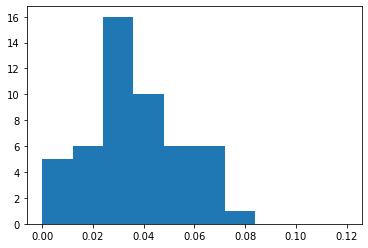

In [61]:
plt.hist(xMI[y], range=(0,0.12))

(array([ 5., 20., 20., 28., 14.,  9.,  1.,  2.,  0.,  1.]),
 array([0.01446594, 0.02626941, 0.03807289, 0.04987636, 0.06167983,
        0.0734833 , 0.08528678, 0.09709025, 0.10889372, 0.12069719,
        0.13250067]),
 <BarContainer object of 10 artists>)

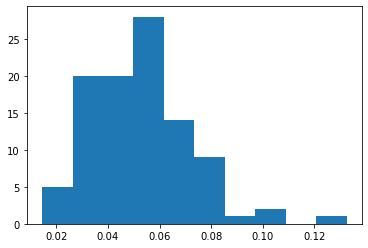

In [60]:
plt.hist(xMI[y == False])

In [63]:
scipy.stats.kendalltau(data[0], data[1]).correlation

0.07858500580117998

In [65]:
pc=0
coopIds, compIds = [0,5],[1,2,3,4]

data = np.load(f'{datadir}/lstms-pca_matchup-0_map-0_repeat-0.npy')[..., pc]
xTau = np.array([scipy.stats.kendalltau(data[0], data[1]).correlation])[:,np.newaxis]
y = np.array([True])
for map in range(25):
    data = np.load(f'{datadir}/lstms-pca_matchup-0_map-{map}_repeat-0.npy')[..., pc]#[0][:,np.newaxis]
    for count,pair in zip(range(6),combinations(np.arange(4),2)):
        if map!=0 or count!=0:
            t = np.array([scipy.stats.kendalltau(data[pair[0]], data[pair[1]]).correlation])[:,np.newaxis]
            xTau = np.concatenate((xTau, t))
            y = np.concatenate((y, [count in coopIds]))

In [68]:
trainTau = xTau[len(xTau)//4:].reshape(-1, 1)
testTau = xTau[:len(xTau)//4].reshape(-1, 1)
trainY = y[len(y)//4:]
testY = y[:len(y)//4]

print(xTau.shape)

(150, 1)


In [69]:
model = sklearn.linear_model.LogisticRegression().fit(trainTau, trainY)
r_sq = model.score(testTau, testY)
print(f'r sq: {r_sq}')

predY = model.predict(testTau)
cm = confusion_matrix(testY, predY)
print ("Confusion Matrix: \n", cm)

r sq: 0.6486486486486487
Confusion Matrix: 
 [[24  0]
 [13  0]]


(array([ 1.,  1.,  3.,  8., 11., 11.,  7.,  7.,  1.,  0.]),
 array([-0.1  , -0.075, -0.05 , -0.025,  0.   ,  0.025,  0.05 ,  0.075,
         0.1  ,  0.125,  0.15 ]),
 <BarContainer object of 10 artists>)

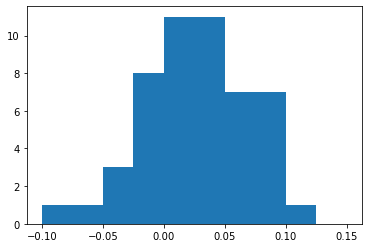

In [75]:
plt.hist(xTau[y], range=(-0.1,0.15))

(array([ 4.,  8., 10., 17., 17., 15., 14., 10.,  3.,  2.]),
 array([-0.09737214, -0.07310194, -0.04883174, -0.02456153, -0.00029133,
         0.02397887,  0.04824907,  0.07251927,  0.09678947,  0.12105968,
         0.14532988]),
 <BarContainer object of 10 artists>)

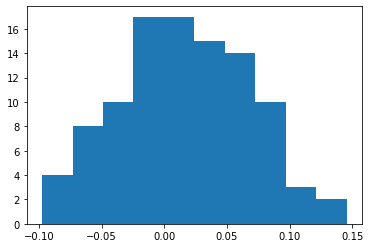

In [72]:
plt.hist(xTau[y == False])